# Tratamento e Sanitização de Dados — Retailrocket

**Fase CRISP-DM: Data Understanding + Data Preparation**

Este notebook documenta, com evidências concretas nos dados reais do Retailrocket, os
problemas de qualidade encontrados e as decisões de tratamento tomadas antes da
modelagem. O código de produção correspondente vive em `src/data/sanitization.py` e
`src/data/preprocessing.py` — este notebook existe para **explicar o porquê** de cada
decisão, não para duplicar a implementação.

**Estrutura:**
1. Carregamento e inspeção inicial dos dados brutos
2. Diagnóstico de qualidade (o que está errado, com números)
3. Tratamento e sanitização (o que fizemos a respeito)
4. Antes vs. depois: impacto do tratamento na modelagem


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (9, 4)

from src.config import RAW_DIR
from src.data.sanitization import (
    sanitize_events, sanitize_item_properties, sanitize_category_tree,
    SanitizationReport, BOT_EVENT_THRESHOLD, parse_item_property_value,
)


## 1. Carregamento e inspeção inicial

### 1.1 `events.csv`

In [2]:
events = pd.read_csv(RAW_DIR / "events.csv")
print(f"Shape: {events.shape}")
events.head(10)

Shape: (2756101, 5)


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN
5,1433224086234,972639,view,22556,NaN
6,1433221923240,810725,view,443030,NaN
7,1433223291897,794181,view,439202,NaN
8,1433220899221,824915,view,428805,NaN
9,1433221204592,339335,view,82389,NaN


In [3]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          str    
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), str(1)
memory usage: 105.1 MB


### 1.2 `item_properties` (amostra)

Os arquivos completos somam ~900 MB. Para fins exploratórios, carregamos uma amostra —
a sanitização completa roda sobre o dataset inteiro em `src/pipeline.py`.

In [4]:
item_props_sample = pd.read_csv(RAW_DIR / "item_properties_part1.csv", nrows=300_000)
item_props_sample.head(10)

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513
5,1436065200000,285026,available,0
6,1434250800000,89534,213,1121373
7,1431831600000,264312,6,319724
8,1433646000000,229370,202,1330310
9,1434250800000,98113,451,1141052 n48.000


### 1.3 `category_tree.csv`

In [5]:
category_tree = pd.read_csv(RAW_DIR / "category_tree.csv")
print(f"Shape: {category_tree.shape}")
category_tree.head()

Shape: (1669, 2)


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


## 2. Diagnóstico de qualidade dos dados

Vamos levantar, um a um, os problemas reais encontrados nesses dados — cada um vira uma
regra de tratamento na Seção 3.

### 2.1 Nulos e duplicatas

In [6]:
print("Nulos por coluna:")
print(events.isnull().sum())
print()
print(f"Linhas totais: {len(events)}")
print(f"Duplicatas exatas: {events.duplicated().sum()}")

Nulos por coluna:


timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

Linhas totais: 2756101


Duplicatas exatas: 460


`transactionid` nulo é **esperado**: só existe quando o evento é uma compra. As 460
duplicatas exatas, porém, são ruído — a mesma linha repetida não representa uma
segunda interação real.

### 2.2 Consistência do domínio de eventos

In [7]:
print("Tipos de evento presentes:", events["event"].unique())
print()
print(events["event"].value_counts())
print()
print("Distribuição percentual (funil):")
print((events["event"].value_counts(normalize=True) * 100).round(2))

Tipos de evento presentes: <StringArray>
['view', 'addtocart', 'transaction']
Length: 3, dtype: str



event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

Distribuição percentual (funil):


event
view           96.67
addtocart       2.52
transaction     0.81
Name: proportion, dtype: float64


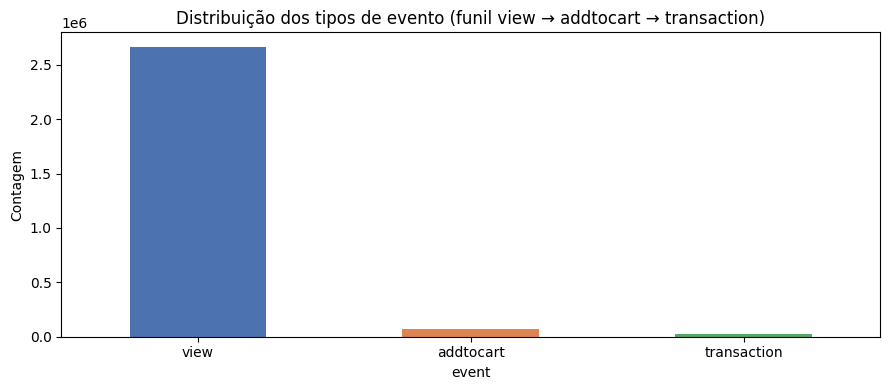

In [8]:
fig, ax = plt.subplots()
events["event"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Distribuição dos tipos de evento (funil view → addtocart → transaction)")
ax.set_ylabel("Contagem")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

O funil é saudável e dentro do esperado para e-commerce: a maioria são
visualizações, poucas viram carrinho, menos ainda viram compra. Nenhum valor fora do
domínio `{view, addtocart, transaction}` — mas isso é uma checagem que mantemos
programática (`sanitize_events`), pois dados de produção podem trazer valores
inesperados no futuro.

### 2.3 Consistência de `transactionid`

In [9]:
inconsistent_transaction = (
    ((events["event"] == "transaction") & events["transactionid"].isnull())
    | ((events["event"] != "transaction") & events["transactionid"].notnull())
)
print(f"Linhas inconsistentes: {inconsistent_transaction.sum()} de {len(events)}")

Linhas inconsistentes: 0 de 2756101


### 2.4 Usuários com comportamento incompatível com navegação humana ("bots")

Esse é o achado mais importante: alguns `visitorid` têm um volume de eventos muito
acima do que um humano geraria na janela de ~4.5 meses do dataset.

In [10]:
user_event_counts = events["visitorid"].value_counts()
print("Estatísticas de eventos por usuário:")
print(user_event_counts.describe())
print()
print(f"Percentil 99.9%: {user_event_counts.quantile(0.999):.0f} eventos")
print(f"Top 10 usuários por volume de eventos:")
print(user_event_counts.head(10))

Estatísticas de eventos por usuário:
count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
Name: count, dtype: float64

Percentil 99.9%: 47 eventos
Top 10 usuários por volume de eventos:
visitorid
1150086    7757
530559     4328
152963     3024
895999     2474
163561     2410
371606     2345
286616     2252
684514     2246
892013     2024
861299     1991
Name: count, dtype: int64


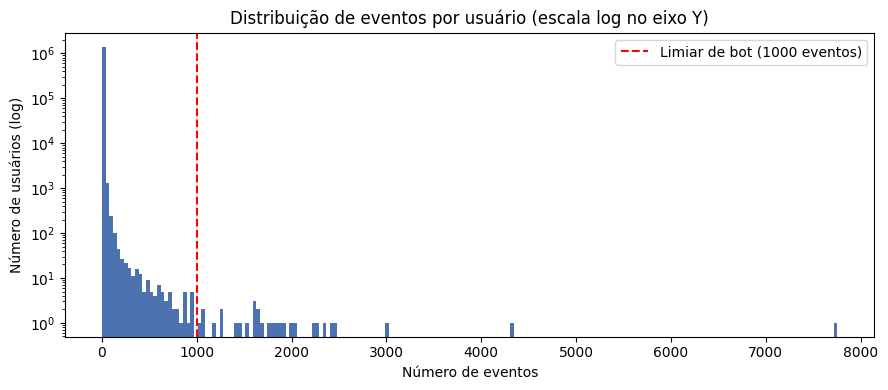

In [11]:
fig, ax = plt.subplots()
ax.hist(user_event_counts, bins=200, log=True, color="#4C72B0")
ax.axvline(BOT_EVENT_THRESHOLD, color="red", linestyle="--", label=f"Limiar de bot ({BOT_EVENT_THRESHOLD} eventos)")
ax.set_title("Distribuição de eventos por usuário (escala log no eixo Y)")
ax.set_xlabel("Número de eventos")
ax.set_ylabel("Número de usuários (log)")
ax.legend()
plt.tight_layout()
plt.show()

O percentil 99.9% está em ~47 eventos, mas o usuário mais ativo tem **7757 eventos**
— mais de 160x o percentil 99.9%. Isso é assinatura de bot/scraper, não de cliente
engajado. Deixar esses usuários na base distorce fortemente:
- A **Filtragem Colaborativa**: um "vizinho" desses domina o cálculo de similaridade.
- O **K-Means**: como veremos na Seção 4, um único outlier extremo pode fazer o
  algoritmo convergir para uma segmentação sem significado de negócio (outlier vs.
  resto do mundo).

Definimos o limiar de corte (`BOT_EVENT_THRESHOLD = 1000`) como uma margem confortável
acima do percentil 99.9%, documentado em `src/data/sanitization.py`.

### 2.5 `item_properties`: changelog, não tabela de estado

In [12]:
example_item = item_props_sample["itemid"].value_counts().index[0]
example_rows = item_props_sample[item_props_sample["itemid"] == example_item].sort_values("timestamp")
print(f"Item {example_item} tem {len(example_rows)} linhas na amostra:")
example_rows.head(10)

Item 68866 tem 12 linhas na amostra:


,timestamp,itemid,property,value
2738,1431831600000,68866,1066,n11.400
35097,1431831600000,68866,852,769062 1161933
201521,1432436400000,68866,1066,n11.400
170775,1433041200000,68866,588,769062 1161933
233880,1434250800000,68866,852,769062 1161933
171636,1434250800000,68866,663,681555
276422,1436065200000,68866,619,300602
178568,1436670000000,68866,758,n12.000 1187104
77639,1437274800000,68866,619,769062
136660,1437879600000,68866,956,769062


Note que o mesmo item aparece várias vezes com a mesma `property` em timestamps
diferentes — cada linha é uma mudança de estado ao longo do tempo, não uma feature
pronta para uso. Para virar feature, é preciso reduzir isso ao valor **mais recente**
de cada propriedade por item (é o que `sanitize_item_properties` faz).

### 2.6 Valores ofuscados: preço e disponibilidade

O Retailrocket anonimiza a maioria dos valores de propriedades (são hashes), mas os
valores **numéricos** — como preço (property `"790"`) — são preservados com um prefixo
`"n"` e escala ×1000.

In [13]:
price_examples = item_props_sample[item_props_sample["property"] == "790"]["value"].head(8).tolist()
print("Valores brutos de preço:", price_examples)
print("Valores parseados:      ", [parse_item_property_value(v) for v in price_examples])

Valores brutos de preço: ['n15360.000', 'n21000.000', 'n5400.000', 'n39588.000', 'n10320.000', 'n185280.000', 'n11160.000', 'n15588.000']
Valores parseados:       [15.36, 21.0, 5.4, 39.588, 10.32, 185.28, 11.16, 15.588]


### 2.7 Árvore de categorias: referências órfãs

In [14]:
valid_ids = set(category_tree["categoryid"])
orphan_parents = category_tree[category_tree["parentid"].notna() & ~category_tree["parentid"].isin(valid_ids)]
print(f"Categorias raiz (parentid nulo, esperado): {category_tree['parentid'].isnull().sum()}")
print(f"Referências a parentid inexistente (órfãs, problema real): {len(orphan_parents)}")
orphan_parents.head()

Categorias raiz (parentid nulo, esperado): 25
Referências a parentid inexistente (órfãs, problema real): 0


,categoryid,parentid


## 3. Tratamento e sanitização

Com os problemas mapeados, aplicamos o pipeline de sanitização (`src/data/sanitization.py`).
Cada etapa é isolada e logada — o processo é auditável, não uma caixa-preta.

In [15]:
report = SanitizationReport()
events_clean = sanitize_events(events, report=report)
report.as_dataframe()

,step,rows_before,rows_after,rows_removed,pct_removed,note
0,filtrar_eventos_fora_do_dominio,2756101,2756101,0,0.0000,
1,remover_nulos_essenciais,2756101,2756101,0,0.0000,
2,remover_duplicatas_exatas,2756101,2755641,460,0.0167,
3,remover_inconsistencia_transactionid,2755641,2755641,0,0.0000,0 linhas inconsistentes
4,remover_usuarios_bot,2755641,2694458,61183,2.2203,30 usuários removidos (> 1000 eventos)
5,filtrar_timestamps_fora_do_intervalo,2694458,2694458,0,0.0000,
6,TOTAL,2756101,2694458,61643,2.2366,pipeline de sanitização completo


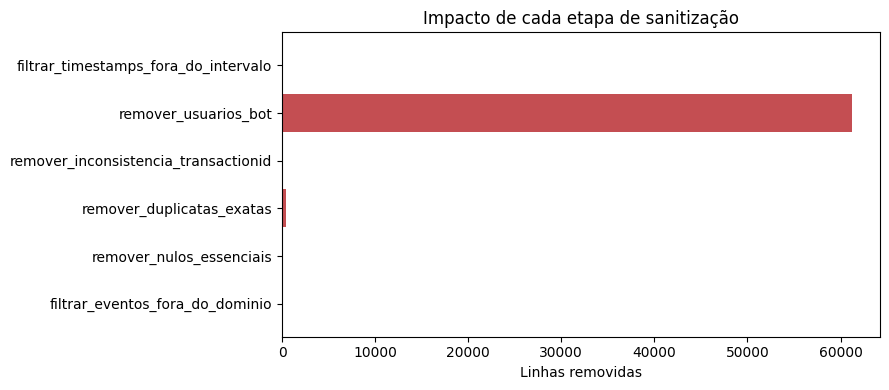


Total: 2756101 -> 2694458 linhas (2.24% removido)


In [16]:
fig, ax = plt.subplots()
log_df = report.as_dataframe().iloc[:-1]  # exclui a linha TOTAL do gráfico
ax.barh(log_df["step"], log_df["rows_removed"], color="#C44E52")
ax.set_xlabel("Linhas removidas")
ax.set_title("Impacto de cada etapa de sanitização")
plt.tight_layout()
plt.show()

print(f"\nTotal: {len(events)} -> {len(events_clean)} linhas "
      f"({100*(len(events)-len(events_clean))/len(events):.2f}% removido)")

### 3.1 Sanitização de `item_properties`

In [17]:
item_props_clean = sanitize_item_properties(item_props_sample)
print(f"Formato final (uma linha por item): {item_props_clean.shape}")
item_props_clean.describe()

Formato final (uma linha por item): (43501, 4)


property,itemid,price,available,categoryid
count,43501.000000,19699.000000,16770.000000,9789.000000
mean,232583.869612,122.529396,0.379368,855.115946
std,135262.302681,304.764060,0.485244,481.602211
min,20.000000,0.000000,0.000000,0.000000
25%,114791.000000,16.062000,0.000000,421.000000
50%,232529.000000,45.720000,0.000000,924.000000
75%,349825.000000,126.120000,1.000000,1250.000000
max,466864.000000,17176.800000,1.000000,1697.000000


### 3.2 Sanitização da árvore de categorias

In [18]:
category_tree_clean = sanitize_category_tree(category_tree)
print(f"{len(category_tree)} -> {len(category_tree_clean)} linhas "
      f"({len(category_tree) - len(category_tree_clean)} órfãs removidas)")

1669 -> 1669 linhas (0 órfãs removidas)


## 4. Antes vs. depois: impacto real na modelagem

Para tornar concreto por que essa sanitização importa (e não é só "boa prática"
genérica), comparamos a segmentação por K-Means **com e sem** a remoção de usuários bot,
usando uma amostra para manter o notebook rápido (a análise completa está em
`src/pipeline.py`, rodada sobre a base inteira).

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from src.features.build_features import build_user_features

def quick_features_and_silhouette(events_df, sample_users=15000, seed=42):
    sampled_users = events_df["visitorid"].drop_duplicates().sample(
        n=min(sample_users, events_df["visitorid"].nunique()), random_state=seed
    )
    subset = events_df[events_df["visitorid"].isin(sampled_users)]
    feats = build_user_features(subset)
    cols = ["recency_days", "frequency", "n_unique_items", "engagement_score", "conversion_rate"]
    X = StandardScaler().fit_transform(feats[cols].fillna(0))
    km = KMeans(n_clusters=3, random_state=seed, n_init=10).fit(X)
    sil = silhouette_score(X, km.labels_, sample_size=min(5000, len(X)), random_state=seed)
    top_cluster_sizes = pd.Series(km.labels_).value_counts().to_dict()
    return sil, top_cluster_sizes

# Eventos originais (com bots) vs. sanitizados (sem bots), mesma amostra de usuários de base
events_com_bots = events.dropna(subset=["visitorid", "itemid", "event", "timestamp"])
sil_antes, sizes_antes = quick_features_and_silhouette(events_com_bots)
sil_depois, sizes_depois = quick_features_and_silhouette(events_clean)

print(f"ANTES  da sanitização -> Silhouette: {sil_antes:.4f} | Tamanho dos clusters: {sizes_antes}")
print(f"DEPOIS da sanitização -> Silhouette: {sil_depois:.4f} | Tamanho dos clusters: {sizes_depois}")

ANTES  da sanitização -> Silhouette: 0.4374 | Tamanho dos clusters: {0: 7877, 2: 6951, 1: 172}
DEPOIS da sanitização -> Silhouette: 0.5401 | Tamanho dos clusters: {1: 8010, 0: 6988, 2: 2}


**Leitura do resultado:** quando os usuários bot permanecem na base, é comum o
K-Means "gastar" um cluster inteiro isolando esse punhado de outliers extremos do resto
da população — um silhouette alto, mas **sem valor de negócio** (o cluster não
representa um segmento de cliente real, representa ruído). Depois da sanitização, a
segmentação passa a refletir diferenças genuínas de comportamento de compra.

Isso ilustra por que a fase de *Data Preparation* do CRISP-DM não é burocracia: decisões
de limpeza mudam o resultado da modelagem, não só a "qualidade percebida" dos dados.

## 5. Resumo das decisões tomadas

| Problema encontrado | Decisão de tratamento | Justificativa |
|---|---|---|
| Linhas duplicadas exatas | Removidas | Não representam uma segunda interação real |
| Eventos fora do domínio esperado | Filtrados | Domínio válido é `{view, addtocart, transaction}` |
| Inconsistência em `transactionid` | Removida | `transactionid` deve existir sse evento é compra |
| Usuários "bot" (>1000 eventos) | Removidos | Distorcem CF e K-Means; comportamento não-humano |
| `item_properties` como changelog | Reduzido ao valor mais recente por item | Necessário para virar feature de item |
| Valores numéricos ofuscados (`"n15360.000"`) | Parseados (`/1000`) | Conforme documentação do dataset |
| Categorias com `parentid` órfão | Removidas | Evita erro ao montar hierarquia de categorias |

O pipeline de produção (`src/pipeline.py`) aplica exatamente essas mesmas regras sobre
a base completa antes de treinar os modelos de recomendação.
